<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/Actividad7PCA_(ADRIAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

*   NOMBRE: Adrian Valdes Zavala
*   MATRÍCULA: A01720439

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [ ]:
print("11 son Numeros / 15 son Textos")
print("Usaremos un valor valido de cada columna ? para saber que tipo de dato es")
print("Despues de los cambios obtuvimos que:")
print("17 son numericas y 9 son textos")
print()
cars_df = pd.read_csv("/content/drive/MyDrive/MaestriaMNA/Ciencia de Datos/automobile_dataset.csv")
print(cars_df.info())

interrogacion = cars_df.columns[cars_df.eq("?").any()]
print(list(interrogacion))

cars_df = cars_df.replace("?", np.nan)
for col in interrogacion:
    ejemplo = cars_df[col].dropna().iloc[0]
    try:
        float(ejemplo)
        cars_df[col] = pd.to_numeric(cars_df[col], errors="coerce")
    except ValueError:
        cars_df[col] = cars_df[col].astype("object")

print(cars_df.info())


11 son Numeros / 15 son Textos
Usaremos un valor valido de cada columna ? para saber que tipo de dato es
Despues de los cambios obtuvimos que:
17 son numericas y 9 son textos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64

# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

No hay duplicados:

0
Porcentaje por columna:
normalized_losses    20.00000
stroke                1.95122
price                 1.95122
bore                  1.95122
horsepower            0.97561
peak_rpm              0.97561
make                  0.00000
fuel_type             0.00000
aspiration            0.00000
symboling             0.00000
wheel_base            0.00000
engine_location       0.00000
drive_wheels          0.00000
body_style            0.00000
num_doors             0.00000
length                0.00000
height                0.00000
width                 0.00000
fuel_system           0.00000
engine_size           0.00000
num_cylinders         0.00000
engine_type           0.00000
curb_weight           0.00000
compression_ratio     0.00000
city_mpg              0.00000
highway_mpg           0.00000
dtype: float64
                   count          mean          std      min      25%  \
symboling          205.0      0.834146     1.245307    -2.00     0.00   
normalized_lo

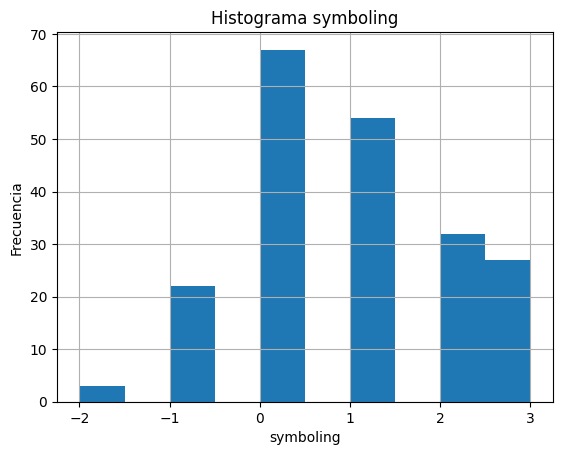

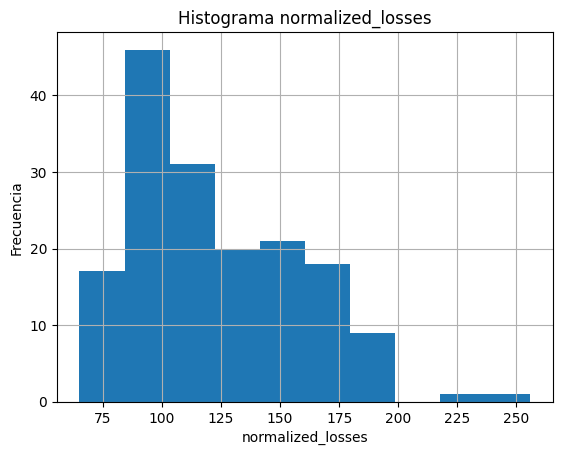

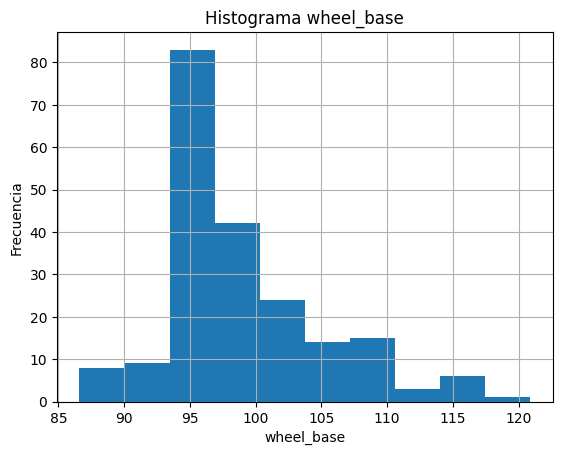

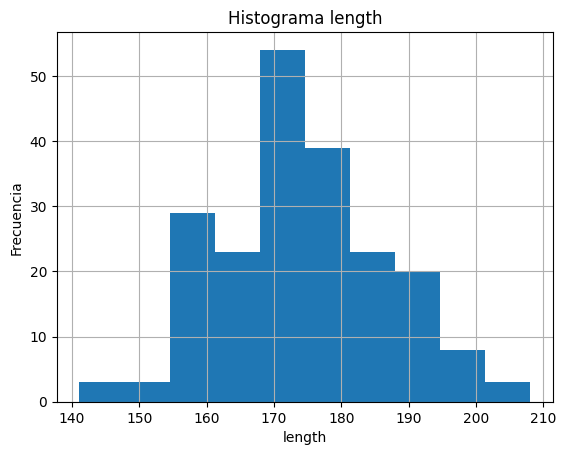

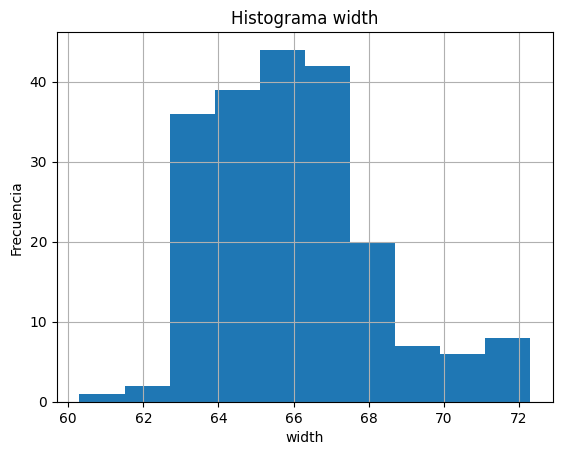

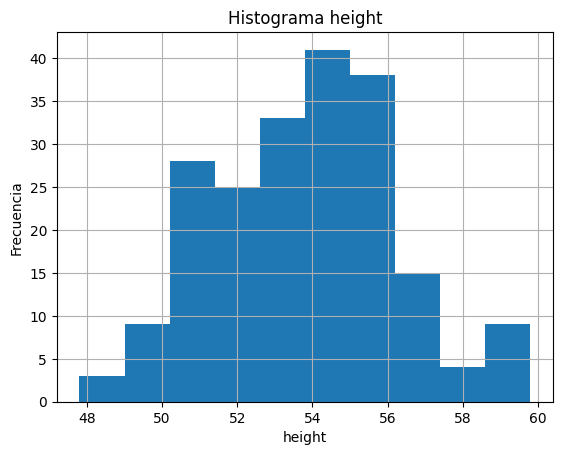

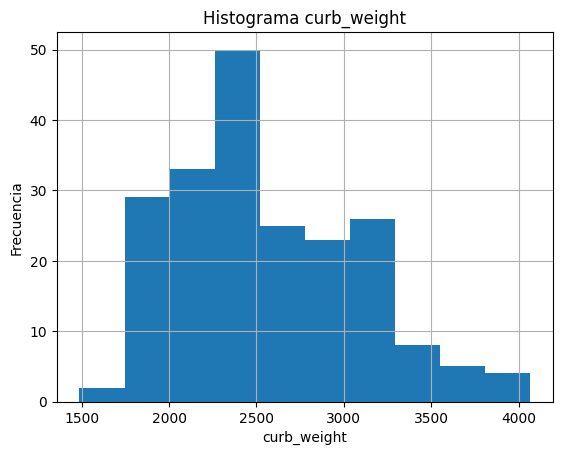

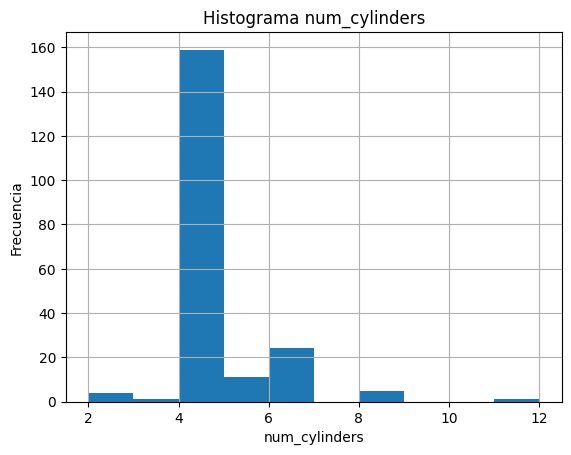

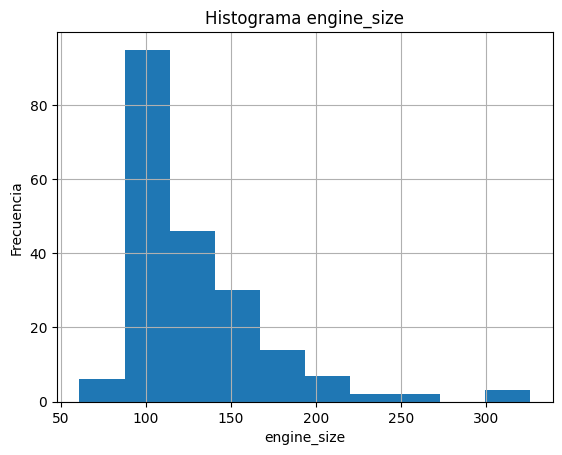

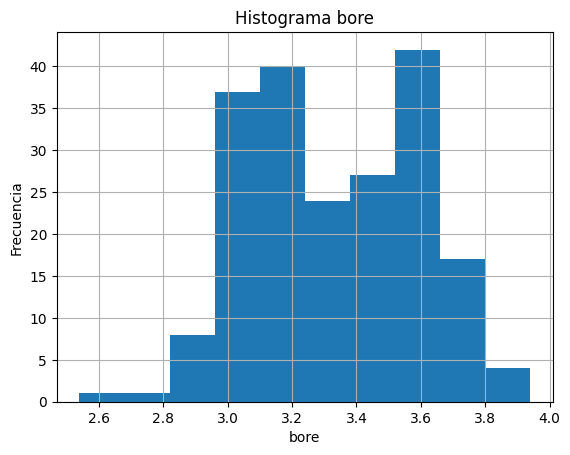

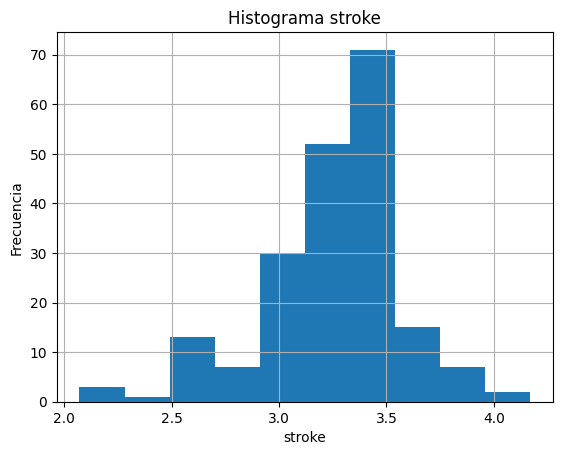

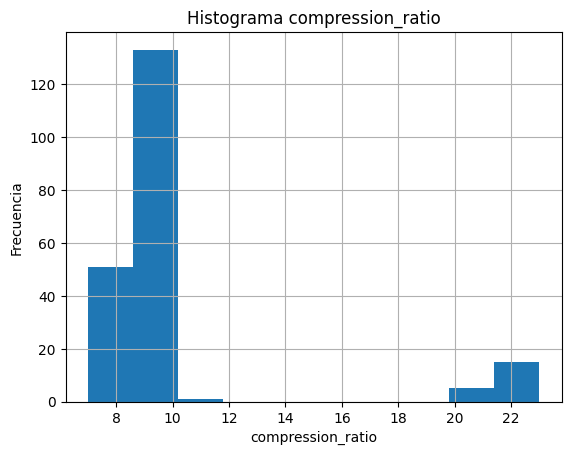

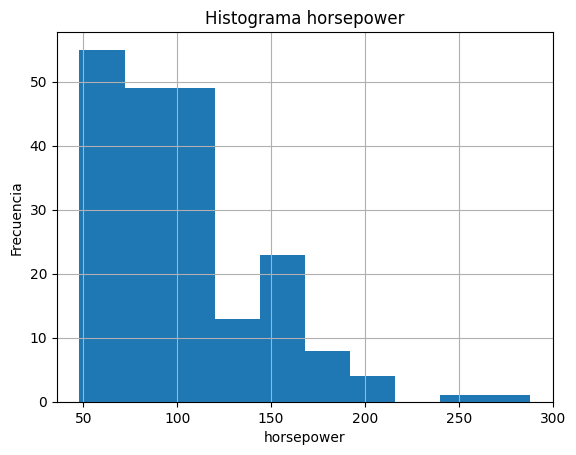

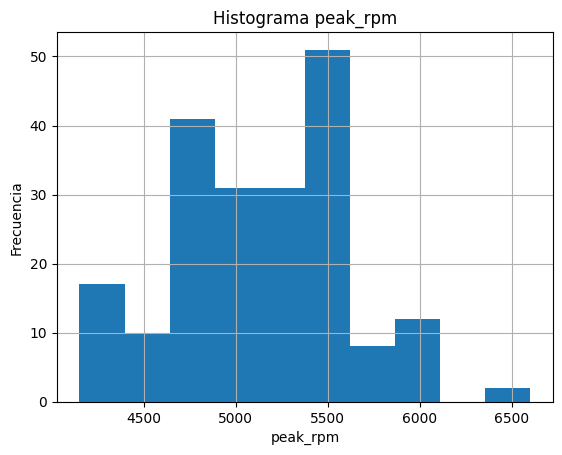

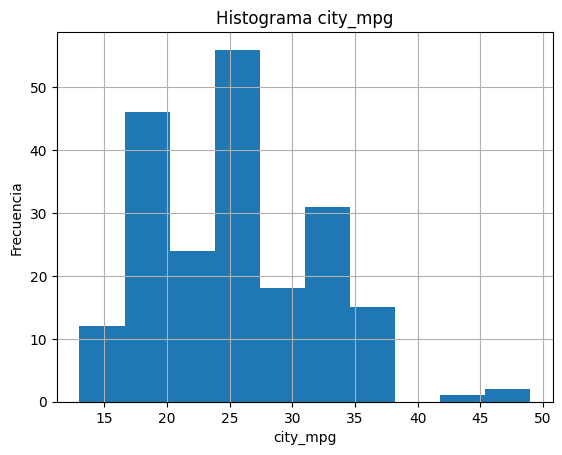

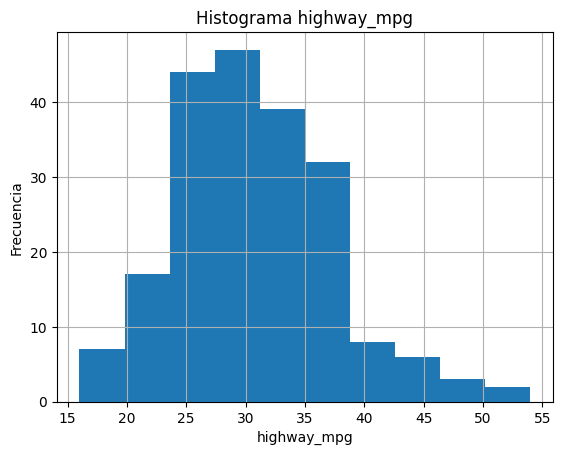

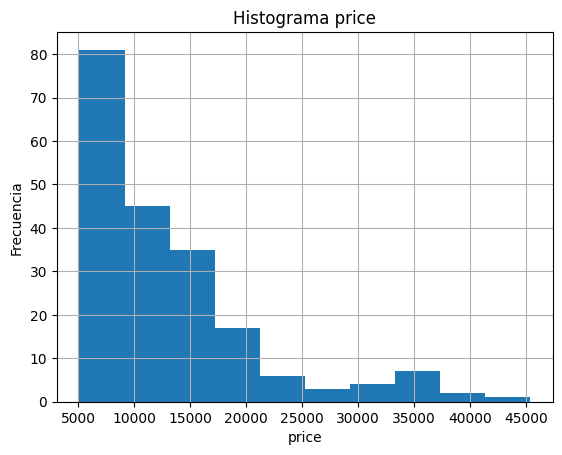

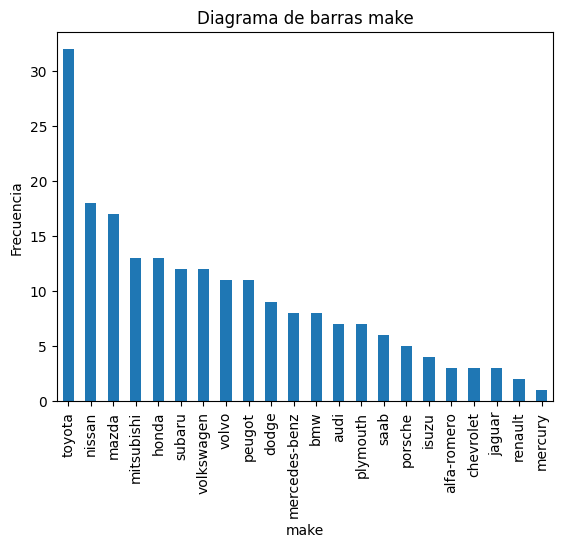

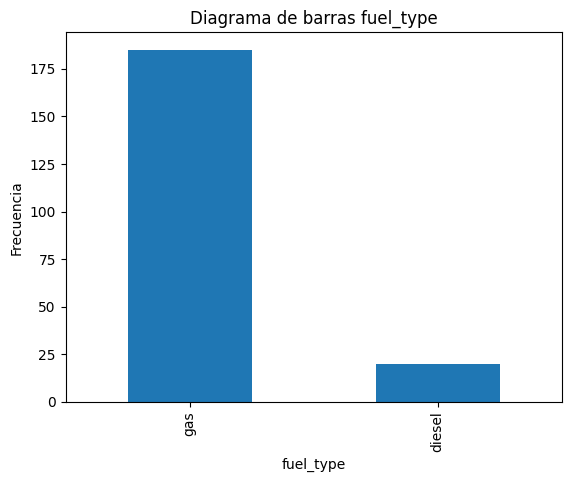

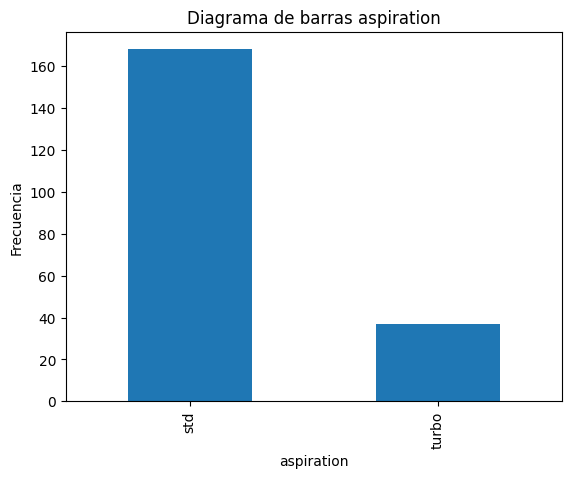

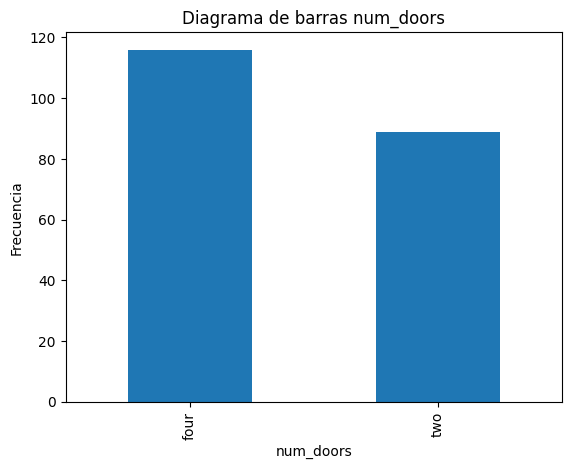

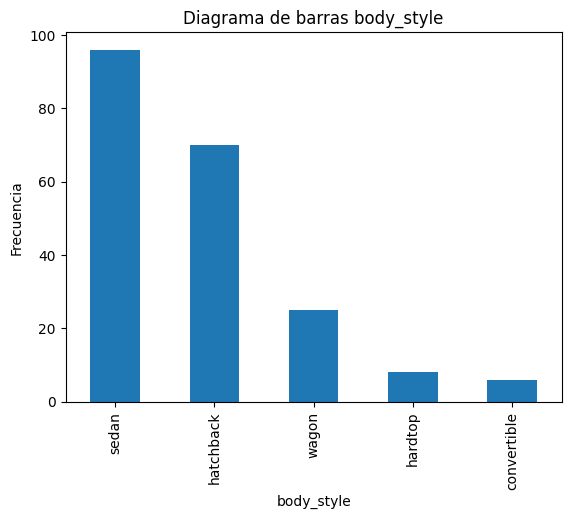

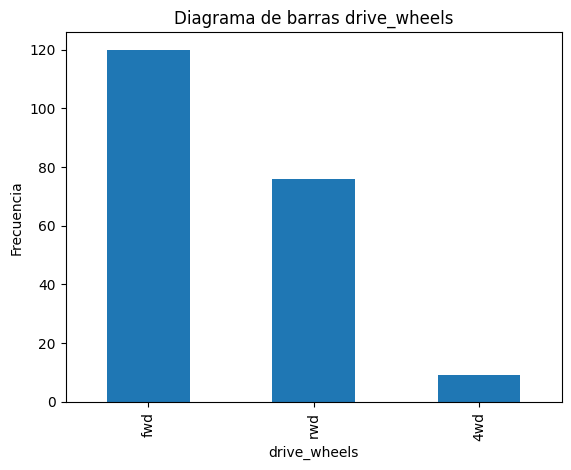

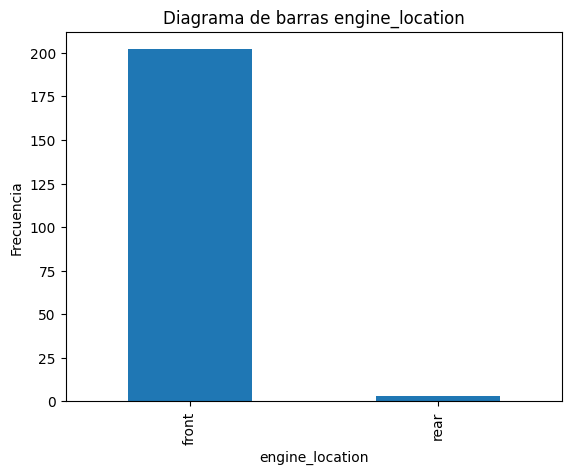

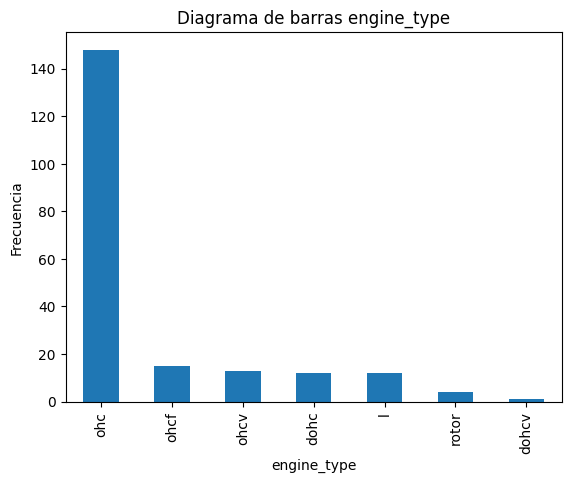

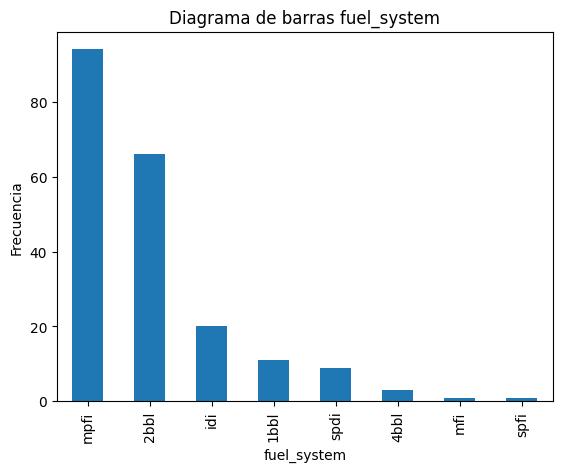

In [ ]:
print("No hay duplicados:")
print()
duplicados = cars_df.duplicated().sum()
print(duplicados)
porcentaje_col = (cars_df.isna().sum() / len(cars_df)) * 100
print("Porcentaje por columna:")
print(porcentaje_col.sort_values(ascending=False))

#Stats Descriptivos
num_cols = cars_df.select_dtypes(include=["number"]).columns
cat_cols = cars_df.select_dtypes(include=["object"]).columns

stats_numericas = cars_df[num_cols].describe().T
stats_numericas["asimetría"] = cars_df[num_cols].skew()
stats_numericas["curtosis"] = cars_df[num_cols].kurt()
stats_categoricas = cars_df[cat_cols].describe().T
print(stats_numericas)
print(stats_categoricas)

#Tablas de Freq
for col in cat_cols:
    print(f"{col}")
    freq = cars_df[col].value_counts(dropna=False)
    porcentaje = cars_df[col].value_counts(normalize=True, dropna=False) * 100
    tabla_frecuencia = pd.DataFrame({"Frecuencia": freq,"Porcentaje (%)": porcentaje})
    print(tabla_frecuencia)

#Diagramas
for col in num_cols:
    cars_df[col].dropna().hist()
    plt.title(f"Histograma {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

for col in cat_cols:
    cars_df[col].value_counts().plot(kind="bar")
    plt.title(f"Diagrama de barras {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()






# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

Conclusiones:
Se puede ver que cada fabricante tiene una clara preferencia. Pero mayormente tiendedn a ser
Traccion Delantera o Trasera, Tambien Mezclar ambas es una opcion algo común para los fabricantes.
Sin Embargo, solo 3 fabricantes usan llantas 4WD y de esos ninguno las usa como su unica opcion
lo cual nos indica que tienen el mercado mas nicho. Cabe mencionar que Toyota es una excepción,
Ya que es la unica marca que maneja las 3 opciones de tracciones de llanta.


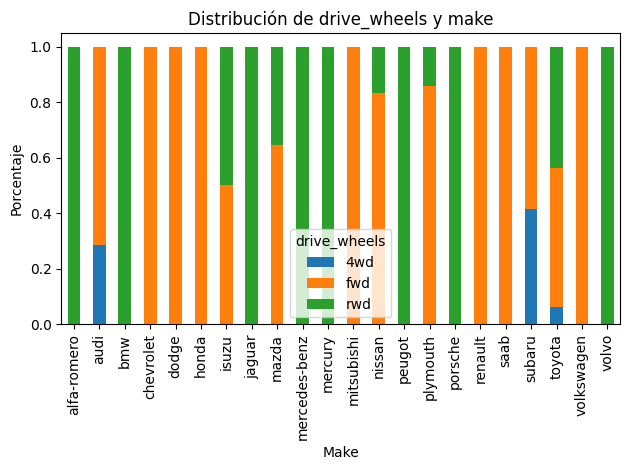

Conclusiones:
Se puede apreciar como autos hatchback, sedans y wagons, suelen ser los mas accesibles al publico,
no tienen tanta diferencia de precio y se mantienen en un rango razonable.
Sin embargo, Convertibles y Hartops, suelen ser mas comúnes en carros deportivos, de colección y de carreras
Normalmente no accesibles al publico general, por lo mismo pueden fluctuar en precio y tener precios muy altos.



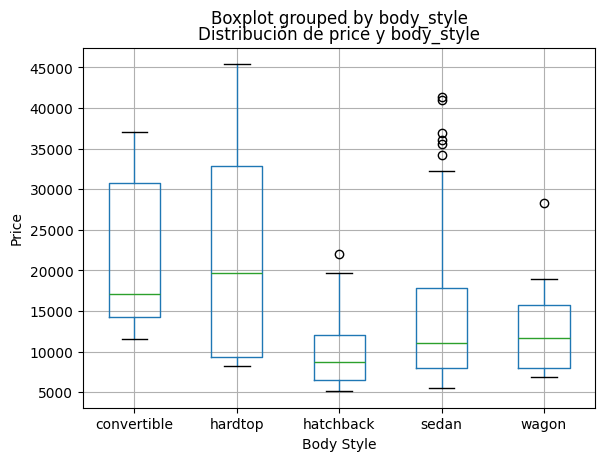

Conclusiones:
Los resultados en general se ven logicos. 9/10 de los autos mas caros corresponden
a marcas premium, por lo cual hace sentido su precio elevado. A axcepcion de VW
la cual no necesariamente se considera marca de lujo, ya que ellos mismos
manejan la marca audi, que es su marca de lujo. Por lo tanto es un poco extraño


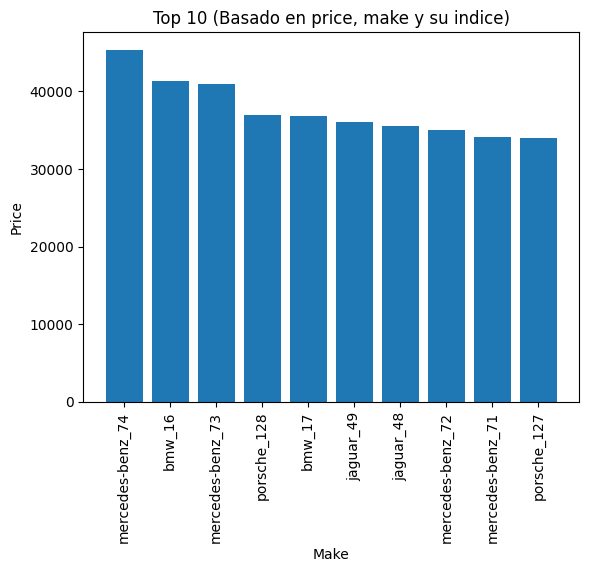

Conclusiones:
De parte de la cantidad de puertas y turbo, realmente no muestra mucha diferencia en el precio en general.
Sin embargo, el tamaño de motor si indica una tendencia muy clara que entre mas grande
suelen ser mas costosos.


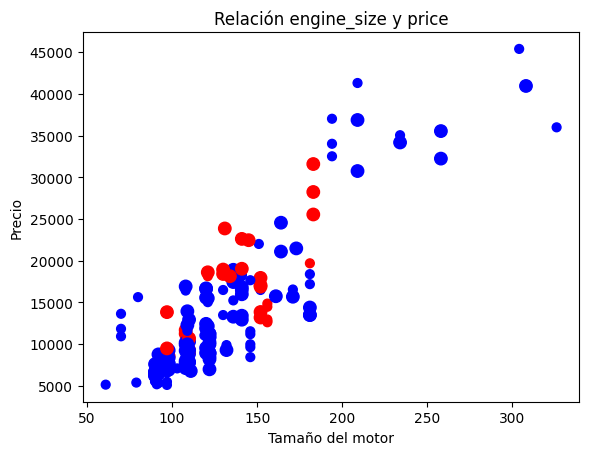

In [ ]:
print("Conclusiones:")
print("Se puede ver que cada fabricante tiene una clara preferencia. Pero mayormente tiendedn a ser")
print("Traccion Delantera o Trasera, Tambien Mezclar ambas es una opcion algo común para los fabricantes.")
print("Sin Embargo, solo 3 fabricantes usan llantas 4WD y de esos ninguno las usa como su unica opcion")
print("lo cual nos indica que tienen el mercado mas nicho. Cabe mencionar que Toyota es una excepción,")
print("Ya que es la unica marca que maneja las 3 opciones de tracciones de llanta.")
bApil = pd.crosstab(cars_df["make"], cars_df["drive_wheels"], normalize="index")
bApil.plot(kind="bar", stacked=True)

plt.title("Distribución de drive_wheels y make")
plt.xlabel("Make")
plt.ylabel("Porcentaje")
plt.tight_layout()
plt.show()

print("Conclusiones:")
print("Se puede apreciar como autos hatchback, sedans y wagons, suelen ser los mas accesibles al publico,")
print("no tienen tanta diferencia de precio y se mantienen en un rango razonable.")
print("Sin embargo, Convertibles y Hartops, suelen ser mas comúnes en carros deportivos, de colección y de carreras")
print("Normalmente no accesibles al publico general, por lo mismo pueden fluctuar en precio y tener precios muy altos.")
print("")
cars_df.boxplot(column="price", by="body_style")

plt.title("Distribución de price y body_style")
plt.xlabel("Body Style")
plt.ylabel("Price")
plt.show()

print("Conclusiones:")
print("Los resultados en general se ven logicos. 9/10 de los autos mas caros corresponden")
print("a marcas premium, por lo cual hace sentido su precio elevado. A axcepcion de VW")
print("la cual no necesariamente se considera marca de lujo, ya que ellos mismos")
print("manejan la marca audi, que es su marca de lujo. Por lo tanto es un poco extraño")

top_10 = cars_df.sort_values("price", ascending=False).head(10)
labels = top_10["make"] + "_" + top_10.index.astype(str)
plt.bar(labels, top_10["price"])
plt.title("Top 10 (Basado en price, make y su indice)")
plt.xlabel("Make")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.show()

print("Conclusiones:")
print("De parte de la cantidad de puertas y turbo, realmente no muestra mucha diferencia en el precio en general.")
print("Sin embargo, el tamaño de motor si indica una tendencia muy clara que entre mas grande")
print("suelen ser mas costosos.")

df = cars_df.copy()
df["num_doors_num"] = df["num_doors"].map({"two": 2, "four": 4})
colors = {"std": "blue", "turbo": "red"}

plt.scatter(df["engine_size"],df["price"],c=df["aspiration"].map(colors),s=df["num_doors_num"]*20)

plt.title("Relación engine_size y price")
plt.xlabel("Tamaño del motor")
plt.ylabel("Precio")
plt.show()


4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

Los 3 valores con mas relación a precio son:
engine_size, curb_weight, horsepower



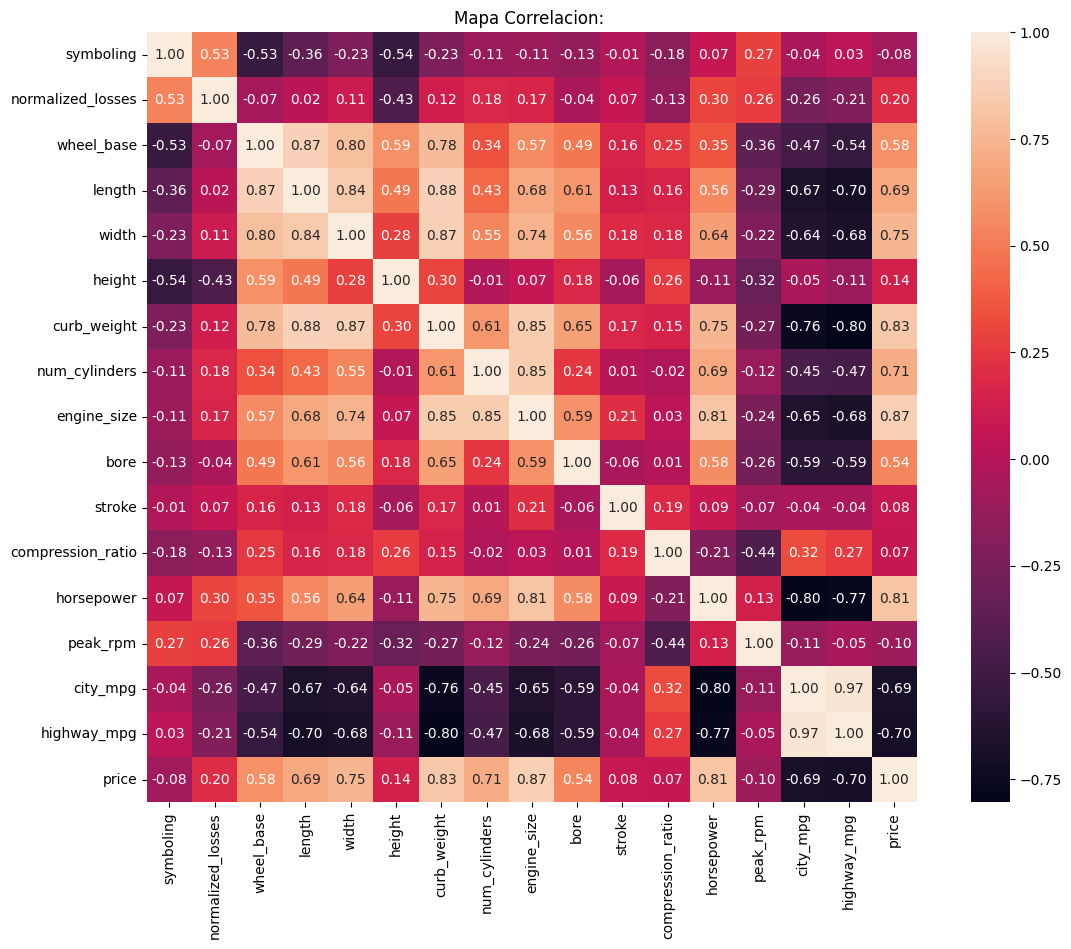

In [ ]:
print("Los 3 valores con mas relación a precio son:")
print("engine_size, curb_weight, horsepower")
print()
numericas = cars_df.select_dtypes(include=["number"])
corr = numericas.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr,annot=True,fmt=".2f",square=True)
plt.title("Mapa Correlacion: ")
plt.show()


En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [ ]:
print("Para SimpleImputer Decidimos usar mean, mientras si hay algunos outliers, no son tantos")
print("ni tan exagerados, por lo tanto creemos que mean quedaria bien.")
print()
numericas = cars_df.select_dtypes(include="number").columns
cars_df[numericas] = SimpleImputer(strategy="mean").fit_transform(cars_df[numericas])
print(cars_df[numericas] )

print("La cantidad de componentes generados por PCA es basicamente la misma cantidad a las columnas")
print("consideraras, entonces si tengo 16 columnas numericas, PCA genera 16 componentes.")
print()
y = cars_df["price"]
X = cars_df.select_dtypes(include="number").drop(columns=["price"])
X = X.dropna()

pca = PCA()
X_pca = pca.fit_transform(X)

print(X.shape[1])
print(X_pca)

print("Definimos standardScaler para que todas las variables contribuyan equitativamente, lo aplicamos en la sig pregunta")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



Para SimpleImputer Decidimos usar mean, mientras si hay algunos outliers, no son tantos
ni tan exagerados, por lo tanto creemos que mean quedaria bien.

     symboling  normalized_losses  wheel_base  length  width  height  \
0          3.0              122.0        88.6   168.8   64.1    48.8   
1          3.0              122.0        88.6   168.8   64.1    48.8   
2          1.0              122.0        94.5   171.2   65.5    52.4   
3          2.0              164.0        99.8   176.6   66.2    54.3   
4          2.0              164.0        99.4   176.6   66.4    54.3   
..         ...                ...         ...     ...    ...     ...   
200       -1.0               95.0       109.1   188.8   68.9    55.5   
201       -1.0               95.0       109.1   188.8   68.8    55.5   
202       -1.0               95.0       109.1   188.8   68.9    55.5   
203       -1.0               95.0       109.1   188.8   68.9    55.5   
204       -1.0               95.0       109.1   188.8  

6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

Aplicamos Scaler
[[-0.910729   -2.46287229 -0.36624909 ...  0.36743668  0.18851873
   0.00638036]
 [-0.910729   -2.46287229 -0.36624909 ...  0.36743668  0.18851873
   0.00638036]
 [ 0.64104961 -1.42095269  0.92708013 ... -0.01715234  0.12513708
  -0.10401019]
 ...
 [ 3.66065689  0.53062302 -1.82082308 ... -0.2733967  -0.02417574
  -0.13871645]
 [ 2.52579109  3.06136792  1.72919677 ... -0.2250429  -0.35131041
   0.16963816]
 [ 2.95750013  1.21017733 -1.72752958 ...  0.07333377 -0.00378558
  -0.21662332]]
Asignamos nombres
          PC1         PC2        PC3        PC4        PC5       PC6  \
0   66.827694 -105.871840   7.058097   9.720645  -6.820327 -4.764705   
1   66.827694 -105.871840   7.058097   9.720645  -6.820327 -4.764705   
2  292.914249   56.021658  11.709316  29.563831 -20.955389 -5.819369   
3 -395.771371  179.198307  33.553797 -15.729939  -1.911530  8.864302   
4    1.591516  461.590049  23.067562 -28.784151   5.147557 -0.433886   

        PC7       PC8       PC9      PC1

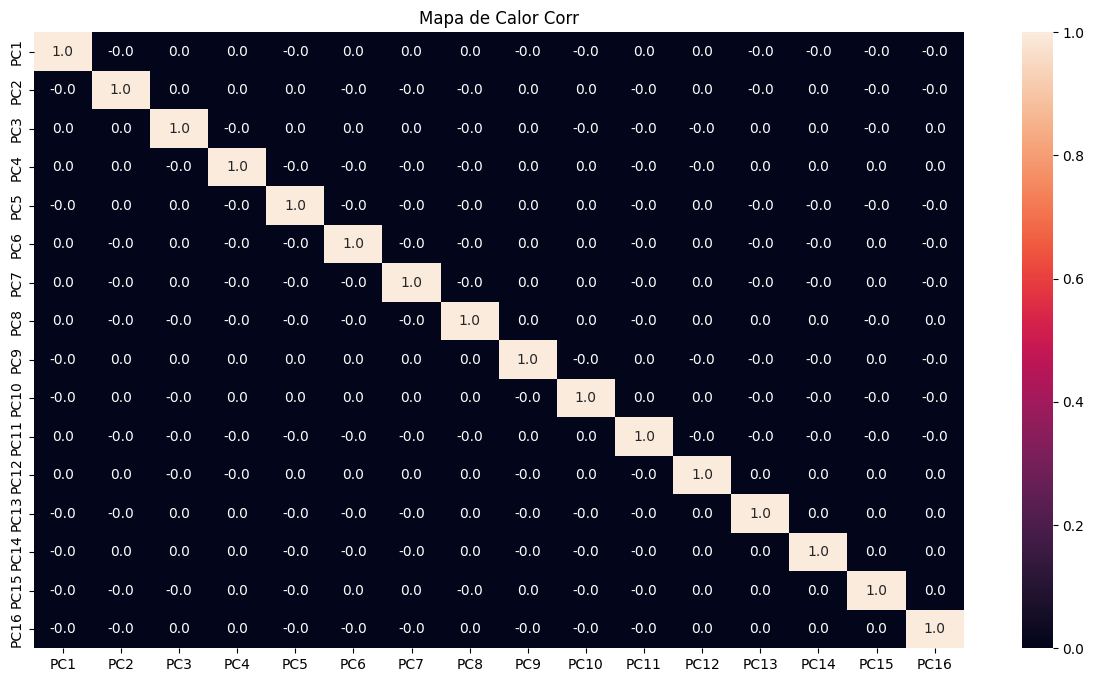

In [ ]:
print("Aplicamos Scaler")
pca_scaled = PCA()
X_pca_scaled = pca_scaled.fit_transform(X_scaled)
print(X_pca_scaled)

print("Asignamos nombres")
pc_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pc_names, index=X.index)
print(X_pca_df.head(5))

print("Generamos mapa de calor")
corr_matrix = X_pca_df.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".1f")
plt.title("Mapa de Calor Corr")
plt.show()




7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

Usamos explained_variance_ratio_ extraido de scikit-learn's PCA
PC1: 0.4458
PC2: 0.1803
PC3: 0.0864
PC4: 0.0635
PC5: 0.0572
PC6: 0.0475
PC7: 0.0324
PC8: 0.0270
PC9: 0.0193
PC10: 0.0155
PC11: 0.0074
PC12: 0.0063
PC13: 0.0051
PC14: 0.0035
PC15: 0.0016
PC16: 0.0012


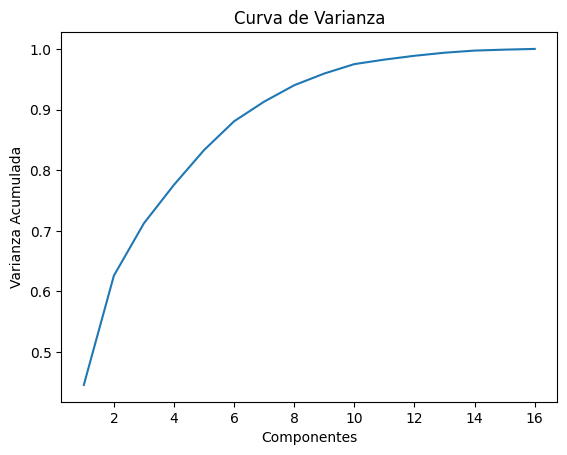

Minimo de componentes: 7


In [ ]:
print("Usamos explained_variance_ratio_ extraido de scikit-learn's PCA")
varianza = pca_scaled.explained_variance_ratio_
for i, v in enumerate(varianza, start=1):
    print(f"PC{i}: {v:.4f}")

varianza_acumulada = np.cumsum(varianza)

plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada)
plt.xlabel('Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Curva de Varianza')
plt.show()

arriba_de_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Minimo de componentes: {arriba_de_90}")



8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

Para sacar las cargas el secreto es la funcion components_ de scikit-learn

     symboling  normalized_losses  wheel_base    length     width    height  \
PC1  -0.095818           0.030606    0.297125  0.337239  0.334068  0.112466   
PC2  -0.404121          -0.338734    0.266442  0.140940  0.057700  0.422562   
PC3   0.260707           0.312286   -0.030437 -0.045336  0.104657 -0.278123   
PC4  -0.078548          -0.319166   -0.223240 -0.190461 -0.094902 -0.179867   
PC5  -0.379146          -0.349229   -0.001045 -0.074600 -0.014876 -0.011636   

     curb_weight  num_cylinders  engine_size      bore    stroke  \
PC1     0.361858       0.245235     0.330215  0.262262  0.053202   
PC2     0.024816      -0.113073    -0.079850  0.004136  0.036133   
PC3     0.077773       0.180834     0.199084 -0.141388  0.506992   
PC4    -0.023715       0.556545     0.294453  0.040251 -0.450766   
PC5    -0.042661       0.263262     0.116259 -0.389296  0.552639   

     compression_ratio  horsepower  peak

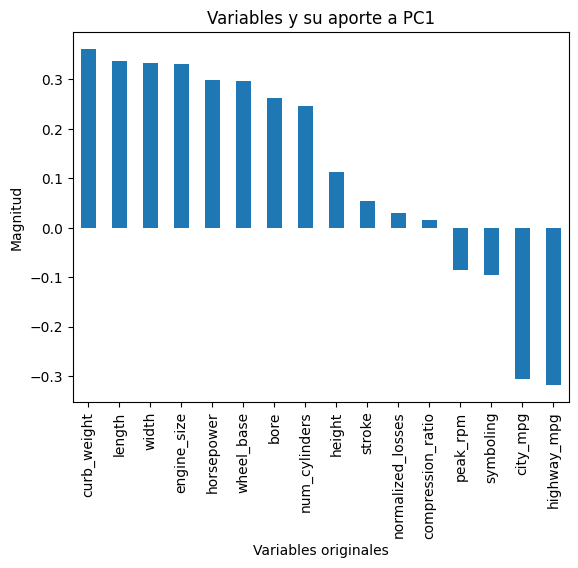

In [ ]:
print("Para sacar las cargas el secreto es la funcion components_ de scikit-learn")
print()
orioginales = X.columns
cargas = pd.DataFrame(pca_scaled.components_,columns=orioginales,
    index=[f"PC{i+1}" for i in range(pca_scaled.n_components_)]).head(5)
print(cargas)
print()

print("A pesar de tener valores negativos, si hablamos de influencia relativa")
print("donde consideramos la magnitud, entonces podemos ignorar los simbolos - y +")
print()
cargas_PC1 = cargas.loc["PC1"]
pc1_sorted = cargas_PC1.sort_values(ascending=False)
pc1_sorted.plot(kind="bar")
plt.title("Variables y su aporte a PC1")
plt.ylabel("Magnitud")
plt.xlabel("Variables originales")
plt.show()



9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [ ]:
print("Ya teniamos cat_cols, entonces solo la voy a llamar")
print()
onehot_df = pd.get_dummies(cars_df, columns=cat_cols, drop_first=True)
print(onehot_df.head())


Ya teniamos cat_cols, entonces solo la voy a llamar

   symboling  normalized_losses  wheel_base  length  width  height  \
0        3.0              122.0        88.6   168.8   64.1    48.8   
1        3.0              122.0        88.6   168.8   64.1    48.8   
2        1.0              122.0        94.5   171.2   65.5    52.4   
3        2.0              164.0        99.8   176.6   66.2    54.3   
4        2.0              164.0        99.4   176.6   66.4    54.3   

   curb_weight  num_cylinders  engine_size  bore  ...  engine_type_ohcf  \
0       2548.0            4.0        130.0  3.47  ...             False   
1       2548.0            4.0        130.0  3.47  ...             False   
2       2823.0            6.0        152.0  2.68  ...             False   
3       2337.0            4.0        109.0  3.19  ...             False   
4       2824.0            5.0        136.0  3.19  ...             False   

   engine_type_ohcv  engine_type_rotor  fuel_system_2bbl  fuel_system_4bbl 

10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [ ]:
X_pca_selected = X_pca_scaled[:, :arriba_de_90]
nombres = [f"PC{i+1}" for i in range(arriba_de_90)]
X_pca_df = pd.DataFrame(X_pca_selected, columns=nombres, index=X.index)
cat_onehot = onehot_df.drop(columns=numericas)
df_final = pd.concat([X_pca_df, cat_onehot, y], axis=1)
print(df_final.head(5))
df_final.to_csv("df_final.csv", index=False)




        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.910729 -2.462872 -0.366249  1.354201 -1.913037  1.054132  0.297881   
1 -0.910729 -2.462872 -0.366249  1.354201 -1.913037  1.054132  0.297881   
2  0.641050 -1.420953  0.927080  0.917757  1.831419 -0.758156 -0.607551   
3 -0.341011 -0.915886  0.435219 -1.461309 -0.243596 -0.817464 -0.039104   
4  1.194387 -1.776152  0.157809 -1.049408  0.162319 -0.853585 -0.398916   

   make_audi  make_bmw  make_chevrolet  ...  engine_type_ohcv  \
0      False     False           False  ...             False   
1      False     False           False  ...             False   
2      False     False           False  ...              True   
3       True     False           False  ...             False   
4       True     False           False  ...             False   

   engine_type_rotor  fuel_system_2bbl  fuel_system_4bbl  fuel_system_idi  \
0              False             False             False            False   
1   